## Part 1 – Experimental Design Understanding ##

In [2]:
import numpy as np
import pandas as pd 
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv('../data/snack_consumer_sensory_dataset.csv')
data.head()

,respondent_id,market,age,gender,product,overall_liking,sweetness,crunchiness,oiliness,aftertaste
0,10001,UK,34,Female,A_CrunchyClassic,7,3.0,6.1,5.5,3.9
1,10001,UK,34,Female,B_SweetSpicy,8,7.1,7.1,3.9,5.9
2,10001,UK,34,Female,C_LightBaked,4,3.1,6.5,4.6,2.9
3,10001,UK,34,Female,D_RichCheesy,3,5.2,4.1,6.3,6.0
4,10002,US,50,Female,A_CrunchyClassic,7,2.7,7.9,5.0,2.1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   respondent_id   880 non-null    int64  
 1   market          880 non-null    str    
 2   age             880 non-null    int64  
 3   gender          880 non-null    str    
 4   product         880 non-null    str    
 5   overall_liking  880 non-null    int64  
 6   sweetness       880 non-null    float64
 7   crunchiness     880 non-null    float64
 8   oiliness        880 non-null    float64
 9   aftertaste      880 non-null    float64
dtypes: float64(4), int64(3), str(3)
memory usage: 68.9 KB


In [5]:
# Basic structure
print("\nUnique respondents:", data['respondent_id'].nunique())
print("Unique products:", data['product'].nunique())
print("Unique Product Names:", data['product'].unique())


Unique respondents: 220
Unique products: 4
Unique Product Names: <StringArray>
['A_CrunchyClassic', 'B_SweetSpicy', 'C_LightBaked', 'D_RichCheesy']
Length: 4, dtype: str


In [6]:
# Count number of evaluations per respondent
counts = data.groupby('respondent_id')['product'].nunique()

print("Average products per respondent:", counts.mean())
print("Min products per respondent:", counts.min())
print("Max products per respondent:", counts.max())


Average products per respondent: 4.0
Min products per respondent: 4
Max products per respondent: 4


In [7]:
# Check rows per respondent
data.groupby('respondent_id').size().value_counts()


4    220
Name: count, dtype: int64

In [8]:
data['market'].value_counts()


market
US    476
UK    404
Name: count, dtype: int64

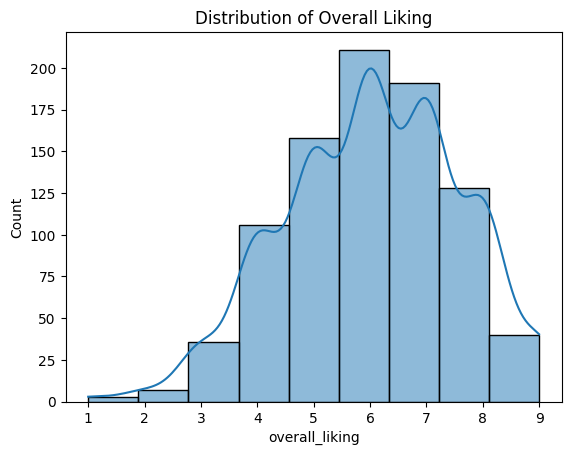

In [9]:
sns.histplot(data['overall_liking'], bins=9, kde=True)
plt.title("Distribution of Overall Liking")
plt.show()


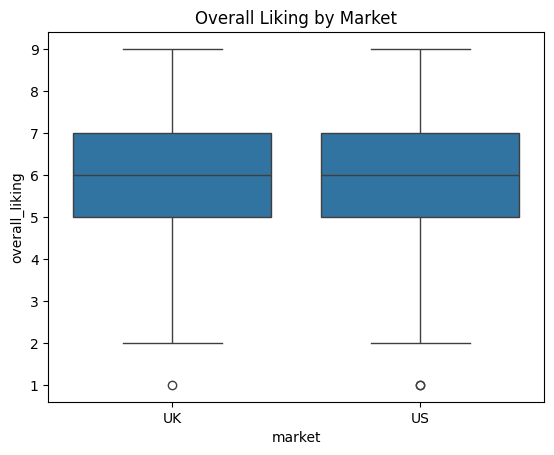

In [10]:
sns.boxplot(
    data=data,
    x="market",
    y="overall_liking"
)

plt.title("Overall Liking by Market")
plt.show()


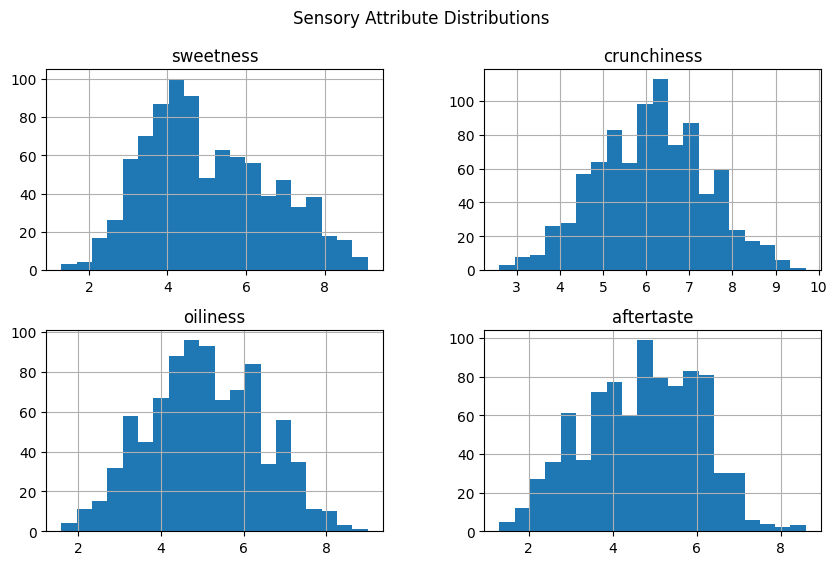

In [12]:
sensory_cols = [
    "sweetness",
    "crunchiness",
    "oiliness",
    "aftertaste"
]

data[sensory_cols].hist(figsize=(10,6), bins=20)
plt.suptitle("Sensory Attribute Distributions")
plt.show()


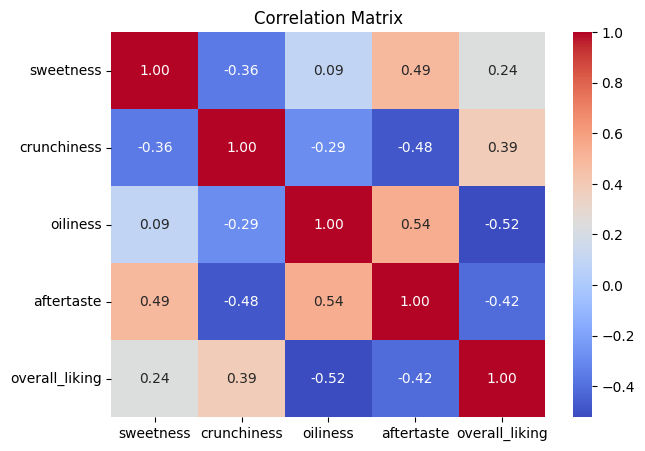

In [13]:
corr = data[sensory_cols + ['overall_liking']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()
